# SECTION 1 — Environment Setup

# Diabetes Classification Experiment

This notebook evaluates the performance of:

- Single classifiers
- CombinedClassifier aggregation

on the Diabetes dataset.

Metrics:
- Accuracy
- F1-score
- Precision
- Recall

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)


# SECTION 2 — Dataset Loading

In [2]:
try:
    from kagglehub import dataset_download
except ImportError:
    %pip install kagglehub
    from kagglehub import dataset_download

path = dataset_download("mathchi/diabetes-data-set")
os.listdir(path)


['diabetes.csv']

In [3]:
df = pd.read_csv(os.path.join(path, "diabetes.csv"))
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# SECTION 3 — Exploratory Data Analysis

In [4]:
print(df.shape)
df.info()

(768, 9)
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

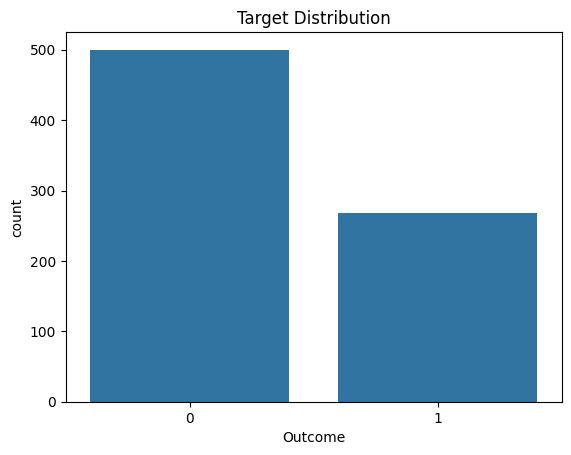

In [6]:
sns.countplot(x=df["Outcome"])

plt.title("Target Distribution")
plt.show()

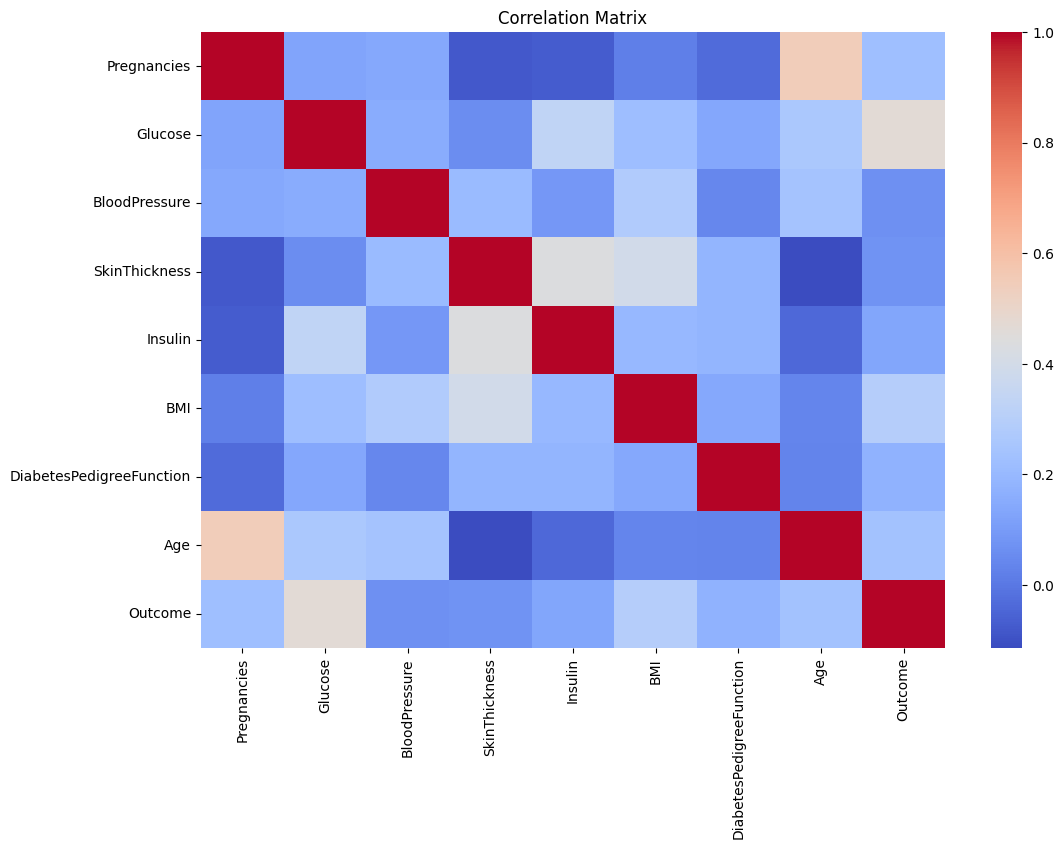

In [7]:
plt.figure(figsize=(12, 8))

sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

# SECTION 4 — Data Preprocessing

In [8]:
X = df.drop(columns=["Outcome"])
y = df["Outcome"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

# SECTION 5 — Train Models

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

models = {
    "logistic_regression": LogisticRegression(),
    "random_forest_classifier": RandomForestClassifier(),
    "svc": SVC(probability=True),
    "k_neighbors_classifier": KNeighborsClassifier(),
    "gaussian_nb": GaussianNB(),
}

def evaluate_classification(y_true, y_pred):
    metrics = {
        "Accuracy" : accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average='weighted'),
        "Recall"   : recall_score(y_true, y_pred, average='weighted'),
        "F1 Score" : f1_score(y_true, y_pred, average='weighted'),
    }
    return metrics

In [11]:
from cobra.combine_classifier import CombineClassifier

results = {}

combined_classifier = CombineClassifier(
    estimators=models.keys(),
    random_state=42,
)
start_fit = time.perf_counter()
combined_classifier.fit(X_train, y_train)
fit_time = time.perf_counter() - start_fit

start_pred = time.perf_counter()
y_pred_combine = combined_classifier.predict(X_test)
predict_time = time.perf_counter() - start_pred

metrics_combine = evaluate_classification(y_test, y_pred_combine)
results["combine_classifier"] = metrics_combine
print(f"Results for combine_classifier: {metrics_combine}\n")
print(f"Time computing : fit {fit_time}, predict {predict_time}")

search: 100%|██████████| 300/300 [00:00<00:00, 327.48it/s]

Results for combine_classifier: {'Accuracy': 0.7142857142857143, 'Precision': 0.7027845036319612, 'Recall': 0.7142857142857143, 'F1 Score': 0.6975098296199214}

Time computing : fit 1.2183066670550033, predict 0.00758387497626245


In [12]:
combined_classifier.optimization_outputs_

{'method': 'grid',
 'optimizer': 'grid',
 'bandwidth': 3.3451471571906355,
 'score': np.float64(0.2116869381279746),
 'history':      iter     score      risk  bandwidth
 0       0  0.341777  0.341777   0.001000
 1       1  0.341777  0.341777   0.034441
 2       2  0.341777  0.341777   0.067883
 3       3  0.341777  0.341777   0.101324
 4       4  0.341777  0.341777   0.134766
 ..    ...       ...       ...        ...
 295   295  0.218244  0.218244   9.866234
 296   296  0.218244  0.218244   9.899676
 297   297  0.218244  0.218244   9.933117
 298   298  0.218244  0.218244   9.966559
 299   299  0.218244  0.218244  10.000000
 
 [300 rows x 4 columns]}

In [13]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    metrics = evaluate_classification(y_test, y_pred)
    results[name] = metrics

In [14]:
results_df = pd.DataFrame(results).T
results_df.sort_values(by="Accuracy", ascending=False)

,Accuracy,Precision,Recall,F1 Score
random_forest_classifier,0.746753,0.742292,0.746753,0.743695
svc,0.720779,0.710619,0.720779,0.703087
combine_classifier,0.714286,0.702785,0.714286,0.697510
logistic_regression,0.714286,0.706464,0.714286,0.708352
gaussian_nb,0.707792,0.717880,0.707792,0.711386
k_neighbors_classifier,0.668831,0.662249,0.668831,0.664832


<Axes: xlabel='bandwidth', ylabel='score'>

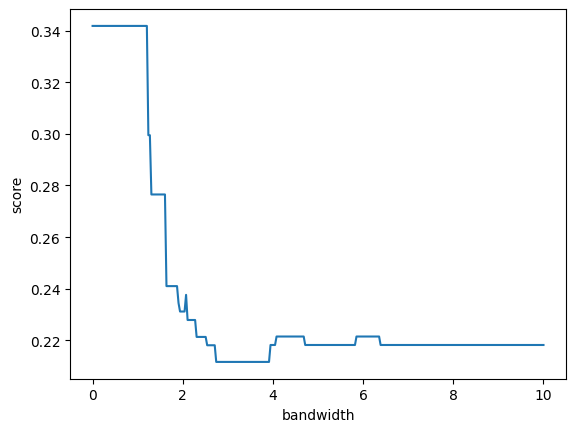

In [15]:
df_output = combined_classifier.optimization_outputs_['history']
sns.lineplot(df_output, x='bandwidth', y='score')

# SECTION 6 — External training

In [16]:
X_base, X_agg, y_base, y_agg = train_test_split(
    X_train,
    y_train,
    test_size=0.5,
    random_state=42,
    stratify=y_train
)

fit_models = {}
for name, model in models.items():
    model.fit(X_base, y_base)
    fit_models[name] = model

P_agg = np.column_stack([
    m.predict(X_agg)
    for m in fit_models.values()
])

P_test = np.column_stack([
    m.predict(X_test)
    for m in fit_models.values()
])

combined = CombineClassifier(
    estimators=fit_models.keys(),
    random_state=42,
)

combined.fit(
    X=P_agg,
    y=y_agg,
    as_predictions=True
)

y_pred = combined.predict(
    X=P_test
)

metrics_combine = evaluate_classification(y_test, y_pred)
metrics_combine


search: 100%|██████████| 300/300 [00:00<00:00, 323.62it/s]


{'Accuracy': 0.7077922077922078,
 'Precision': 0.6972682489923869,
 'Recall': 0.7077922077922078,
 'F1 Score': 0.6800187764043186}